# Exploración, Entrenamiento y MLFlow
Este notebook guía el proceso de exploración, entrenamiento y experimentación con MLFlow para un dataset realista.

In [28]:
from pathlib import Path

print(Path().resolve())          # carpeta actual
print((Path().resolve().parent / ".env").exists())  # debería ser True

/content
False


In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

# Cargar variables locales del proyecto (.env)
load_dotenv(find_dotenv())

project_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
env_file = project_root / ".env"

print(f"Directorio del proyecto: {project_root}")
print(f".env encontrado: {env_file.exists()}")
print("Entorno local listo para continuar con el entrenamiento.")

In [ ]:
# Verificar que environment.yml esté disponible de forma local
from pathlib import Path

project_root = Path.cwd() if (Path.cwd() / "environment.yml").exists() else Path.cwd().parent
local_env_yml = project_root / "environment.yml"

if not local_env_yml.exists():
    raise FileNotFoundError(f"No se encontró environment.yml en {local_env_yml}")

print(f"environment.yml detectado en: {local_env_yml}")

In [ ]:
# 1. Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report

ModuleNotFoundError: No module named 'mlflow'

## 2. Cargar el dataset
Ajusta la ruta y el nombre del archivo según tu dataset.

In [ ]:
from pathlib import Path

# Cambia 'data/dataset.csv' por el nombre de tu archivo
filename = "Bank Customer Churn Prediction.csv"
candidates = [
    Path.cwd() / "data" / filename,                 # si ejecutas desde la raíz del repo
    Path.cwd().parent / "data" / filename,          # si ejecutas desde /notebooks
    Path("/workspaces/MLOps-Fast-API/data") / filename,  # ruta absoluta en dev container
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        f"No se encontró '{filename}'. Rutas probadas:\n" + "\n".join(str(p) for p in candidates)
    )

df = pd.read_csv(data_path)
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Análisis exploratorio básico
Visualiza la estructura y estadísticas del dataset.

## 3.1 Visualización exploratoria avanzada
Incluimos gráficos para entender mejor la distribución y relaciones de las variables.

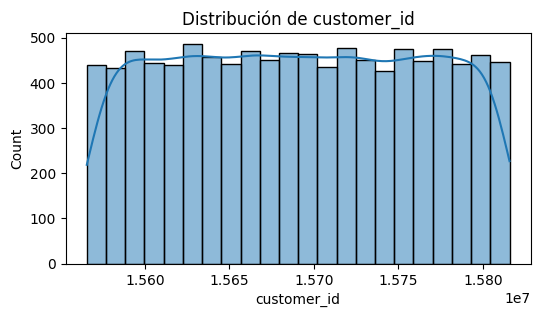

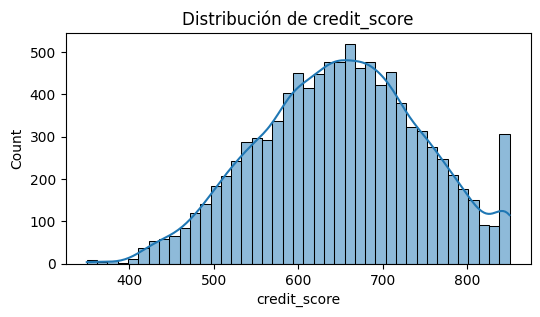

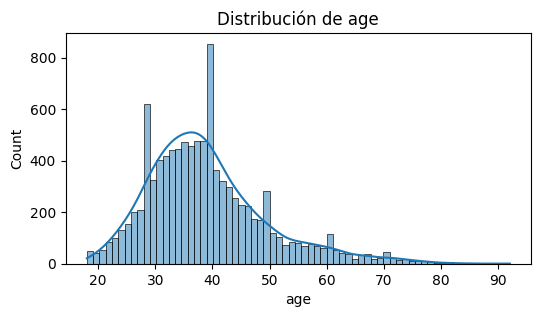

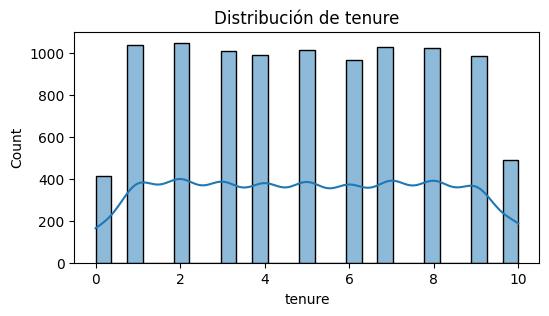

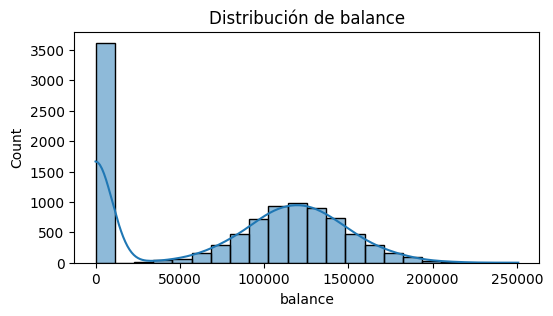

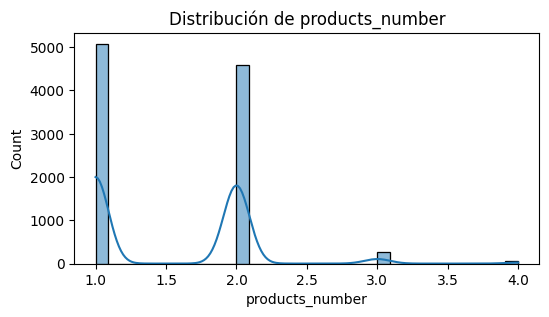

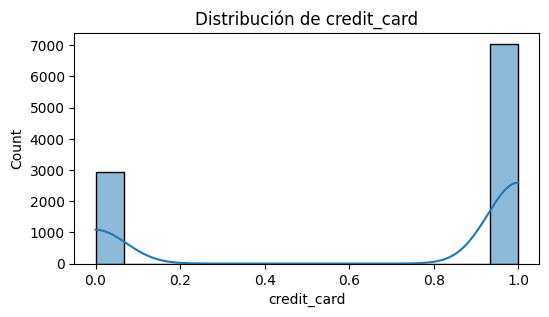

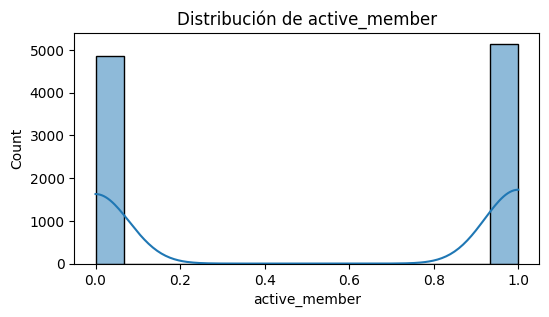

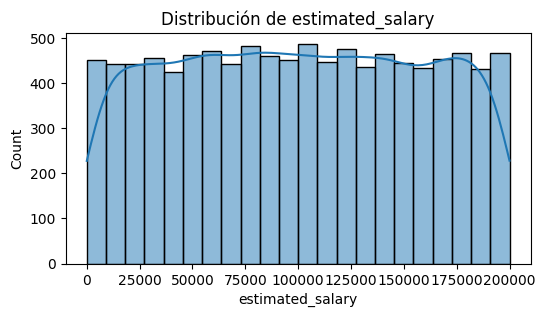

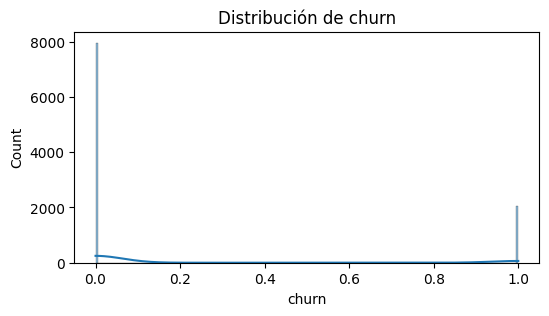

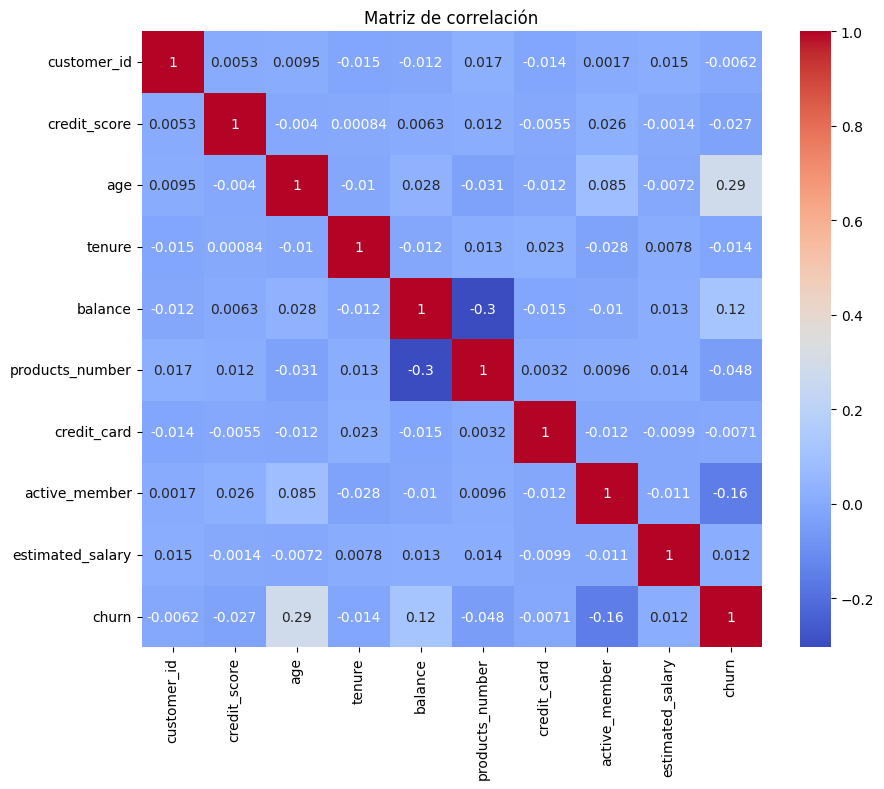

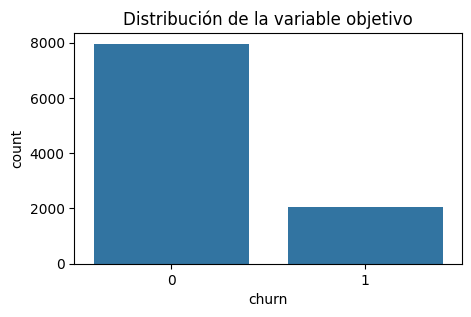

In [ ]:
# Histograma de variables numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

# Conteo de clases objetivo (columna 'churn')
df.columns = [c.lower() for c in df.columns]
if 'churn' not in df.columns:
    raise ValueError('No se encontró la columna objetivo "churn".')
plt.figure(figsize=(5, 3))
sns.countplot(x=df['churn'])
plt.title('Distribución de la variable objetivo')
plt.show()

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 4. Preprocesamiento
Realiza aquí el preprocesamiento necesario (elimina nulos, codifica variables, etc.).

## 4.1 Preprocesamiento avanzado
Incluye codificación de variables categóricas y escalado de variables numéricas.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Codificación de variables categóricas
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Escalado de variables numéricas
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,-0.783213,-0.326221,-0.901886,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1.977165
1,-0.606534,-0.440036,1.515067,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-0.505775
2,-0.995885,-1.536794,-0.901886,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1.977165
3,0.144767,0.501521,-0.901886,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,-0.505775
4,0.652659,2.063884,1.515067,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.505775


In [ ]:
# Ejemplo: eliminar filas con nulos
df = df.dropna()

## 5. División en train/test
Ajusta las variables X e y según tu problema.

In [ ]:
# División en train/test usando la columna objetivo 'churn'
df.columns = [c.lower() for c in df.columns]
target_col = 'churn'
if target_col not in df.columns:
    raise ValueError('No se encontró la columna objetivo "churn".')
X = df.drop(target_col, axis=1)
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 6. Entrenamiento y logging con MLFlow
Ejemplo con RandomForest y logging manual.

## 6.1 Modelo de Deep Learning (Keras)
Entrenamiento de una red neuronal simple para clasificación de churn.

In [ ]:
# Usar la variable objetivo 'churn'
df.columns = [c.lower() for c in df.columns]
target_col = 'churn'
if target_col not in df.columns:
    raise ValueError('No se encontró la columna objetivo "churn".')

# Ajuste para binarizar si es necesario
y_train_bin = y_train if set(y_train.unique()) == {0, 1} else (y_train == y_train.max()).astype(int)
y_test_bin = y_test if set(y_test.unique()) == {0, 1} else (y_test == y_test.max()).astype(int)

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train_bin, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Evaluación
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test_bin, y_pred))

/opt/conda/envs/mlops-fastapi/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777633217.053897   79319 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7980 - loss: 0.4735 - val_accuracy: 0.8263 - val_loss: 0.4193
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8264 - loss: 0.4089 - val_accuracy: 0.8475 - val_loss: 0.3871
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8473 - loss: 0.3769 - val_accuracy: 0.8475 - val_loss: 0.3701
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - loss: 0.3602 - val_accuracy: 0.8512 - val_loss: 0.3601
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8536 - loss: 0.3517 - val_accuracy: 0.8550 - val_loss: 0.3556
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8569 - loss: 0.3464 - val_accuracy: 0.8506 - val_loss: 0.3590
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.3426 - val_accuracy: 0.8519 - val_loss: 0.3497
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8597 - loss: 0.3393 - val_accuracy: 0.

In [ ]:
with mlflow.start_run():
    params = {'n_estimators': 100, 'max_depth': 5, 'random_state': 42}
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    mlflow.log_params(params)
    mlflow.log_metric('mse', mse)
    mlflow.log_metric('r2', r2)
    mlflow.sklearn.log_model(model, 'model')
    print(f'MSE: {mse:.2f} | R2: {r2:.2f}')

2026/05/01 11:00:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 11:00:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MSE: 0.65 | R2: 0.33


## 7. Repite experimentos cambiando hiperparámetros
Puedes automatizarlo con bucles o probar autologging.

In [ ]:
# Ejemplo de autologging
mlflow.sklearn.autolog()
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
print('MSE:', mean_squared_error(y_test, preds))

2026/05/01 11:00:40 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd806c71e66464ccaab5ca3a142483a6b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/01 11:00:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MSE: 0.6305552005813628


## 8. Visualiza y compara experimentos en MLFlow UI
Ejecuta en terminal: `mlflow ui` y accede a http://localhost:5000.